# Enzyme Immobilization Strategy: Implementation Showcase

This notebook demonstrates the setup, simulation, and evaluation of various **Spatial Immobilization Designs (SIDs)** for a consecutive two-step enzymatic reaction ($S_1 \xrightarrow{E_A} S_2 \xrightarrow{E_B} S_3$) in a batch reactor. 

The underlying simulation relies on a coupled multiscale DAE (Differential-Algebraic Equation) model built in `Pyomo`. It integrates:
1. **Micro-scale (Pore):** Intra-particle diffusion-reaction boundary value problems (BVP).
2. **Macro-scale (Reactor):** Bulk reactor mass balances and transient Initial Value Problems (IVP).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from typing import Dict, Any, Tuple

# Local application imports
from main import build_reactor_model
import model.solve as solve
import visualization.model_viz as m_viz
import application.enzyme_ratio_optim as er_opt

# Notebook magic for inline plotting
%matplotlib inline

## 1. Configuration of Spatial Immobilization Designs (SIDs)

Here, we define the spatial distributions of Enzyme A ($E_A$) and Enzyme B ($E_B$) along the 1D dimension of the porous support ($x=0$ to $x=L$). The codebase supports two primary paradigms:
* **Single Immobilization ($\alpha$-SID):** $E_A$ and $E_B$ are immobilized in isolated, separate support particles. The model accounts for this by computing independent pore fluxes and a 50:50 particle ratio.
* **Co-immobilization:** Both enzymes reside within the same pore network. We parameterize spatial density functions (e.g., `linear`, `step`) to represent specific architectures like $\gamma$-SID (linear gradients) and $\theta_1$-SID (core-shell step distributions).

In [2]:
# Sample BVP kwargs for inspected SIDs

# Single immobilization baseline (alpha-SID)
bvp_kwargs_alpha = { 
    'adjust_Np': True,
    'enzymeA': {'kinetics_type': 'first_order'},
    'enzymeB': {'kinetics_type': 'first_order'}
}

# Co-immobilization Configuration Dictionary
CO_IMMOBILIZATION_CONFIGS = {
    "beta": {
        "kinetics_type": {'A': 'first_order', 'B': 'first_order'},
        "E_fun": {'A': 'linear', 'B': 'linear'},
        "A_bounds": {'start': 0.5, 'end': 0.5},
        "B_bounds": {'start': 0.5, 'end': 0.5},
        "A_steps": {'up': None, 'down': None},
        "B_steps": {'up': None, 'down': None}
    },
    "gamma": {
        "kinetics_type": {'A': 'first_order', 'B': 'first_order'},
        "E_fun": {'A': 'linear', 'B': 'linear'},
        "A_bounds": {'start': 1.0, 'end': 0.0},
        "B_bounds": {'start': 0.0, 'end': 1.0},
        "A_steps": {'up': None, 'down': None},
        "B_steps": {'up': None, 'down': None}
    },
    "theta1": {
        "kinetics_type": {'A': 'first_order', 'B': 'first_order'},
        "E_fun": {'A': 'step', 'B': 'step'},
        "A_bounds": {'start': 0.0, 'end': 1.0},
        "B_bounds": {'start': 0.0, 'end': 1.0},
        "A_steps": {'up': 0.0, 'down': 0.3},
        "B_steps": {'up': 0.7, 'down': 1.0}
    }
}

## 2. Single Configuration Modeling

In this section, we instantiate and solve the multiscale DAE model for specific standalone SIDs using the robust IPOPT solver wrapper (`solve_model_robust`). The primary goal is to evaluate the intra-particle concentration gradients and observe the resulting transient product yields in the bulk reactor over time.

We investigate three distinct spatial use-cases:
1. **Single ($\alpha$-SID):** The single immobilization scenario. Because enzymes are physically separated, the intermediate $S_2$ must diffuse out into the bulk fluid before it can encounter $E_B$.
2. **Linear ($\gamma$-SID):** Co-immobilized enzymes with opposing linear density gradients along the pore.
3. **Step ($\theta_1$-SID):** Co-immobilized enzymes with a step-wise (core-shell) density distribution.



In [3]:
def test_single_config(
    immobilization: str, 
    decay_coef: Dict[str, float], 
    bvp_kwargs: Dict[str, Any], 
    solver_verbose: bool = False
) -> Tuple[pyo.ConcreteModel, Any]:
    """
    Builds, solves, and visualizes a multiscale reactor model for a single configuration.
    
    Args:
        immobilization: The type of immobilization (e.g., 'single', 'co-immobilization').
        decay_coef: Dictionary containing decay coefficients for enzymes.
        bvp_kwargs: Boundary value problem configuration kwargs.
        solver_verbose: If True, prints detailed solver output.
        
    Returns:
        A tuple containing the solved Pyomo model and the solver results.
    """
    print(f"Building test model for '{immobilization}' configuration...")
    try:
        test_model = build_reactor_model(
            immobilization=immobilization, 
            decay_coef=decay_coef, 
            bvp_kwargs=bvp_kwargs
        )
    except Exception as e:
        raise RuntimeError(f"Failed to build the multiscale model: {e}")

    print("Solving test model...")
    try:
        # Changed to solve_model_robust and bumped max_iter to 200 to match main.py
        solved_model, solver_results = solve.solve_model_robust(
            test_model, max_iter=200, tol=1e-4, verbose=solver_verbose
        )
    except Exception as e:
        raise RuntimeError(f"Solver encountered a critical error: {e}")
        
    # Verify optimization state and visualize
    if solver_results.solver.termination_condition == pyo.TerminationCondition.optimal:
        print("[SUCCESS] Optimization converged to an optimal solution!")
        
        # Extract and print yields matching main.py functionality
        y_S2 = solved_model.S_0['S2', solved_model.time.last()]() / solved_model.S_0['S1', solved_model.time.first()]()
        y_S3 = solved_model.S_0['S3', solved_model.time.last()]() / solved_model.S_0['S1', solved_model.time.first()]()
        print(f"Final S2 yield: {y_S2:.4f}")
        print(f"Final S3 yield: {y_S3:.4f}")
        
        print("\n1. Plotting enzyme profiles...")
        m_viz.plot_enzyme_pore_profiles(solved_model, immobilization=immobilization)
        m_viz.plot_enzyme_decay_profiles(solved_model, decay_coef)
        
        print("\n2. Plotting substrate concentrations...")
        m_viz.plot_substrate_time_profiles(solved_model)
        plt.show()
        
    else:
        print("[WARNING] Optimization did not converge optimally.")
        print(f"Termination condition: {solver_results.solver.termination_condition}")

    return solved_model, solver_results

### **CASE A: Single Immobilization ($\alpha$-SID)**

Simulating the decoupled configuration where $E_A$ and $E_B$ are compartmentalized. We trigger the `build_reactor_model` pipeline with `immobilization='single'`, run the non-linear optimization, and extract visualization profiles for the enzyme density, decay curves, and bulk substrate transients.

Building test model for 'single' configuration...
Discretizing model...
Applying initial guesses for BVP...
Solving test model...
[SUCCESS] Optimization converged to an optimal solution!
Final S2 yield: 0.0184
Final S3 yield: 0.6732

1. Plotting enzyme profiles...


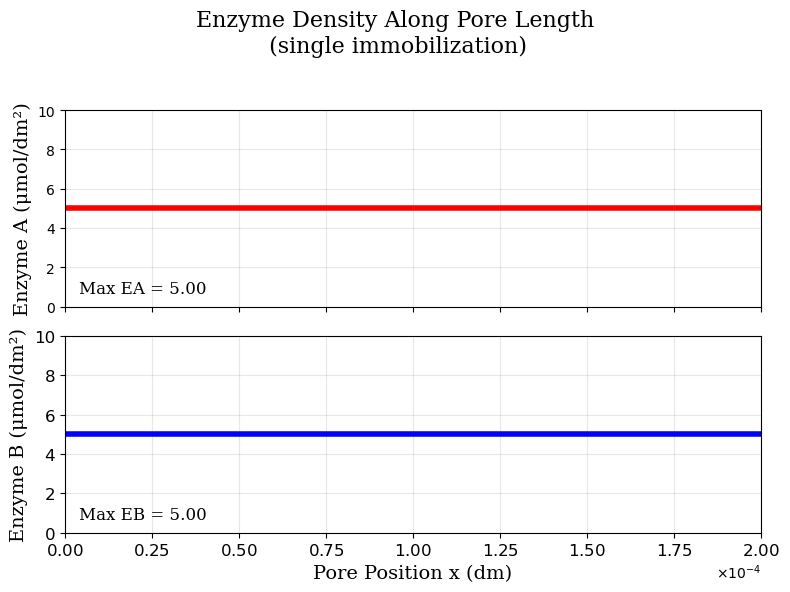

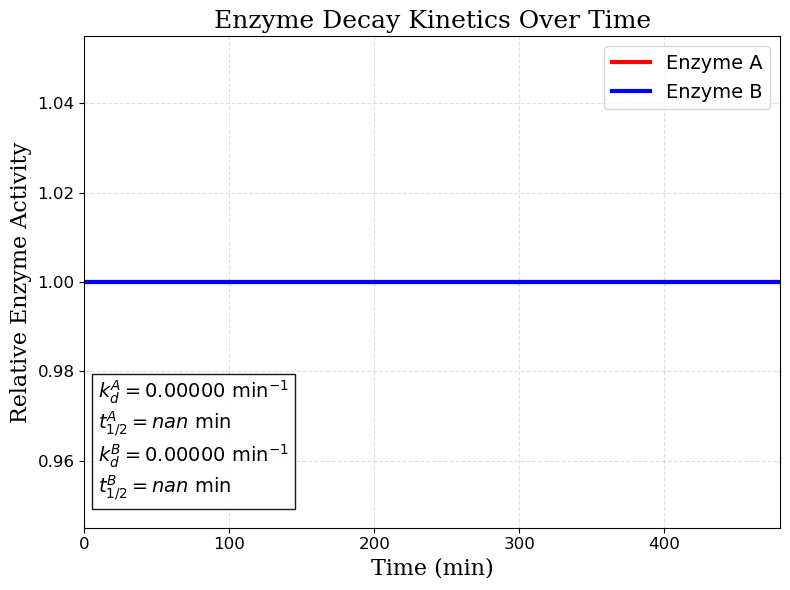


2. Plotting substrate concentrations...


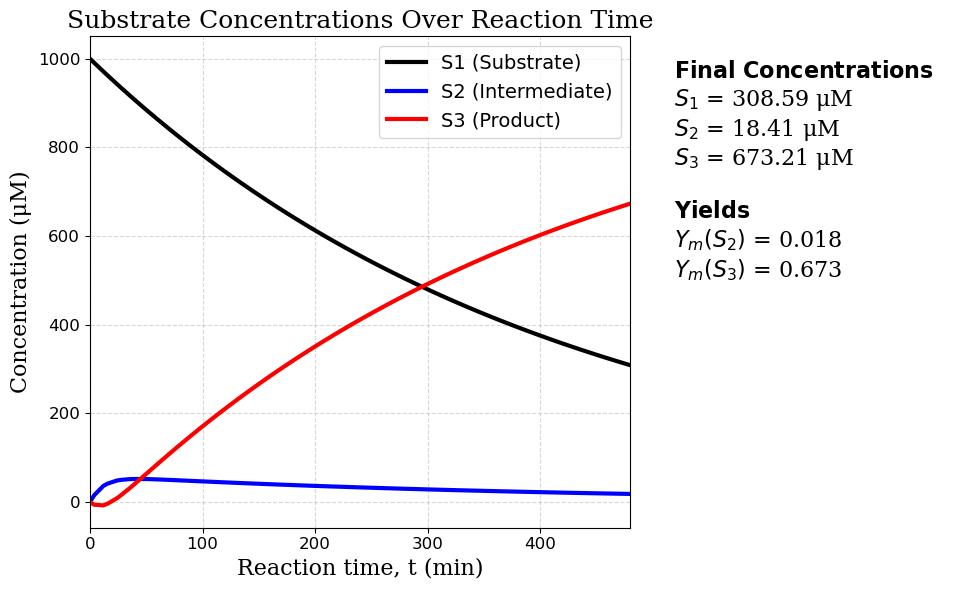

In [8]:
# Set decay coefficients for the test run
decay_coef_base = {'kA': 0.0, 'kB': 0.0}

model_alpha, results_alpha = test_single_config(
    immobilization='single', 
    decay_coef=decay_coef_base, 
    bvp_kwargs=bvp_kwargs_alpha,
    solver_verbose=False # Toggle True to inspect IPOPT logs
)

### **CASE B: co-Immobilization ($\beta$-SID)**

Simulating the coupled configuration where $E_A$ and $E_B$ are co-localized evenly throughout a single shared pore environment. We trigger the `build_reactor_model pipeline` with `immobilization='co-immobilization'` utilizing the beta keyword arguments (linear distributions), run the non-linear optimization, and extract visualization profiles for the shared enzyme density, decay curves, and bulk substrate transients.

Building test model for 'co-immobilization' configuration...
Discretizing model...
Pore count coefficient (EA + EB normalization):
  Avg EA: 5.0645e+00 |  Avg EB: 4.9355e+00
  Avg total enzyme: 1.000000e+01 | Reference total enzyme: 1.0000e+01
  Pore count coefficient: 1.00
Applying initial guesses for BVP...
Solving test model...
[SUCCESS] Optimization converged to an optimal solution!
Final S2 yield: 0.0096
Final S3 yield: 0.9216

1. Plotting enzyme profiles...


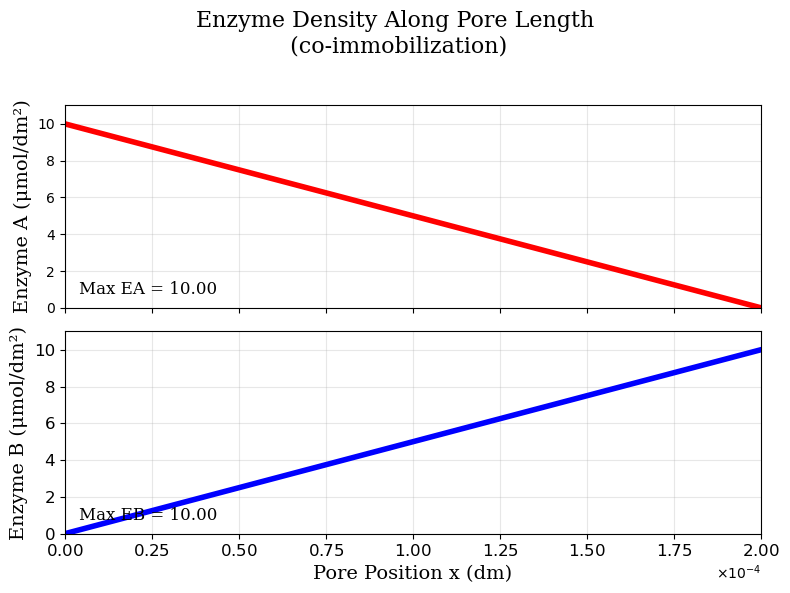

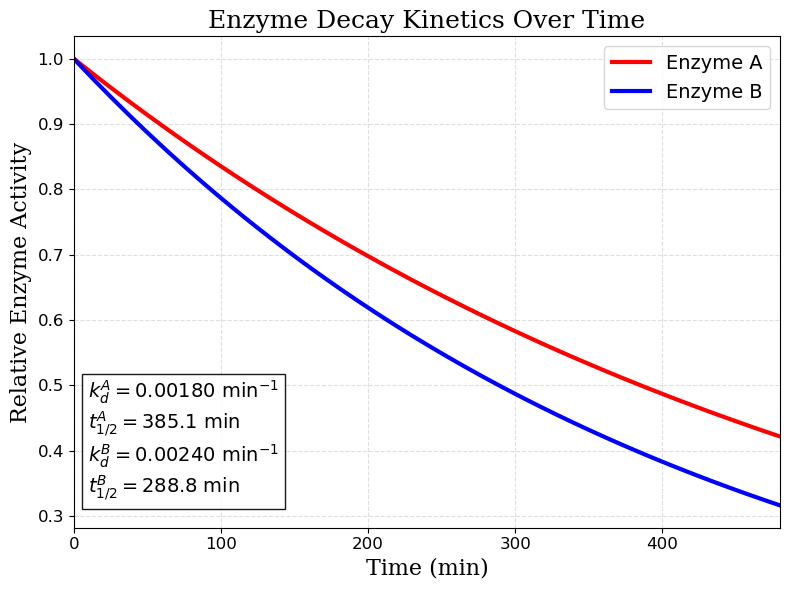


2. Plotting substrate concentrations...


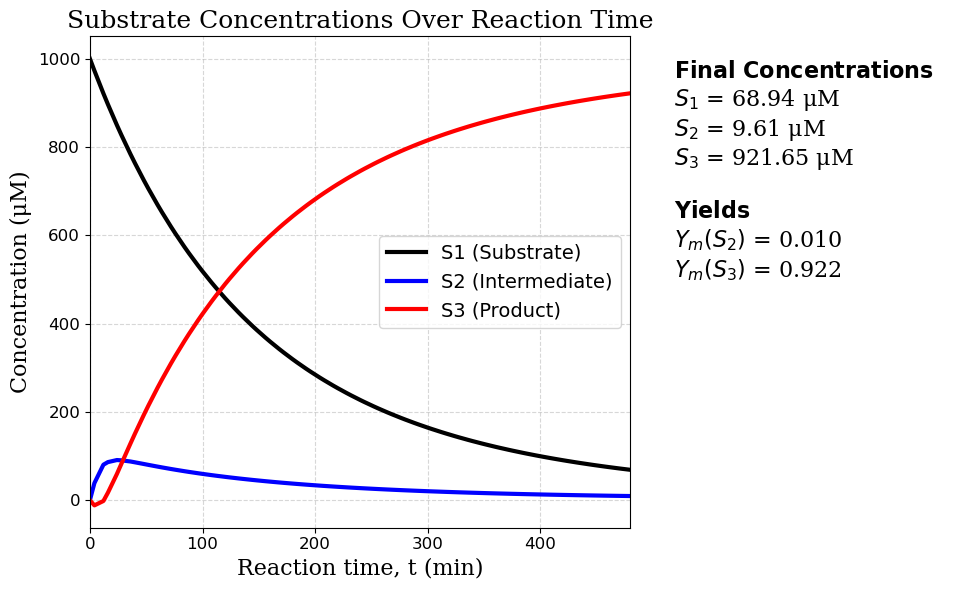

In [4]:
# Set decay coefficients for the test runs
decay_coef_base = {'kA': 0.0018, 'kB': 0.0024}
bvp_kwargs_gamma = {
    'default_fun': 'linear', 
    'adjust_Np': True,
    'enzymeA': {
        'kinetics_type': 'first_order',
        'fun': 'linear',
        'start': 1.0, 
        'end': 0.0
    },
    'enzymeB': {
        'kinetics_type': 'first_order',
        'fun': 'linear',
        'start': 0.0, 
        'end': 1.0
    }
}
model_gamma, results_gamma = test_single_config(
    immobilization='co-immobilization', 
    decay_coef=decay_coef_base, 
    bvp_kwargs=bvp_kwargs_gamma,
    solver_verbose=False  # Toggle True to inspect IPOPT logs
)

### **CASE C: Stepwise Co-Immobilization ($\theta1$-SID)**
Simulating the spatially structured coupled configuration where $E_A$ and $E_B$ are segregated into distinct layers within the same shared pore ($E_A$ localized near the pore mouth, and $E_B$ localized near the dead-end). 

We trigger the `build_reactor_model pipeline` with `immobilization='co-immobilization'` utilizing the theta1 keyword arguments (step-function distributions), run the non-linear optimization, and extract visualization profiles for the stratified enzyme density, decay curves, and bulk substrate transients.

Building test model for 'co-immobilization' configuration...
Discretizing model...
Pore count coefficient (EA + EB normalization):
  Avg EA: 2.9032e+00 |  Avg EB: 2.8997e+00
  Avg total enzyme: 5.802899e+00 | Reference total enzyme: 1.0000e+01
  Pore count coefficient: 1.72
Applying initial guesses for BVP...
Solving test model...
[SUCCESS] Optimization converged to an optimal solution!
Final S2 yield: 0.0023
Final S3 yield: 0.9881

1. Plotting enzyme profiles...


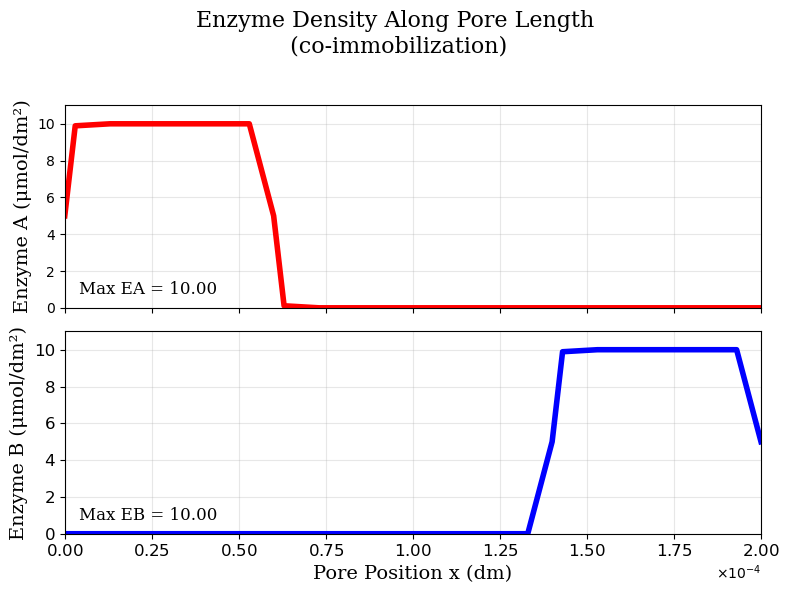

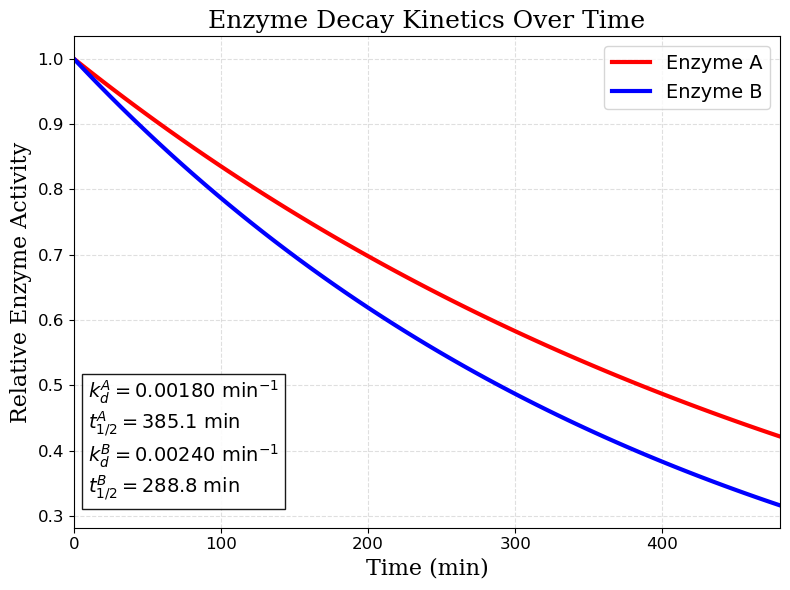


2. Plotting substrate concentrations...


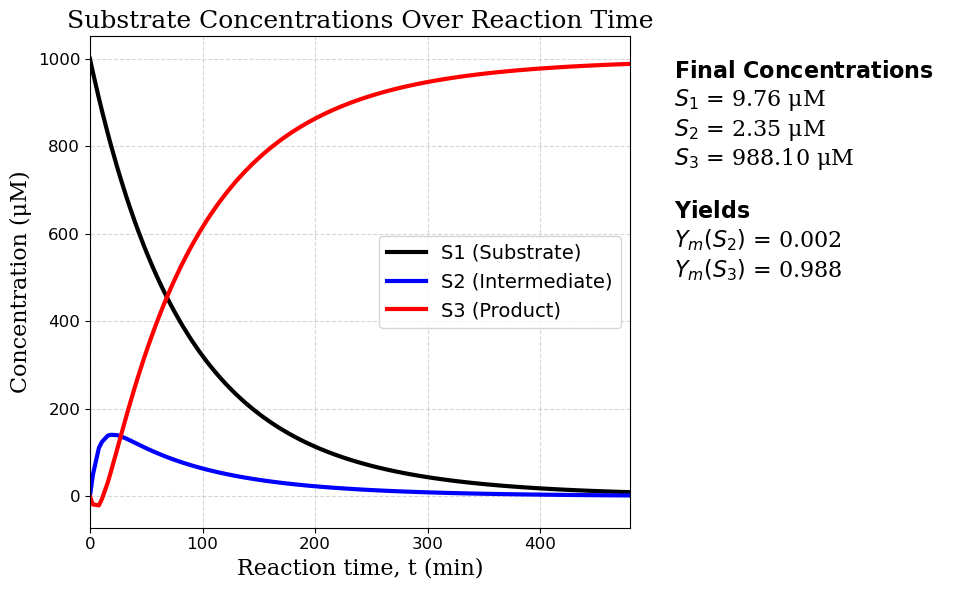

In [4]:
# Set decay coefficients for the test runs
decay_coef_base = {'kA': 0.0018, 'kB': 0.0024}
bvp_kwargs_theta1 = {
    'default_fun': 'step', 
    'adjust_Np': True,
    'enzymeA': {
        'kinetics_type': 'first_order',
        'fun': 'step',
        'start': 0.0, 
        'end': 1.0, 
        'x_step_up': 0.0, 
        'x_step_down': 0.3, 
        'smoothness': 300
    },
    'enzymeB': {
        'kinetics_type': 'first_order',
        'fun': 'step',
        'start': 0.0, 
        'end': 1.0,
        'x_step_up': 0.7, 
        'x_step_down': 1.0,
        'smoothness': 300
    }
}

model_theta, results_theta = test_single_config(
    immobilization='co-immobilization', 
    decay_coef=decay_coef_base, 
    bvp_kwargs=bvp_kwargs_theta1,
    solver_verbose=False  # Toggle True to inspect IPOPT logs
)

## 3. Enzyme Ratio Optimization

For a fixed total enzyme loading budget ($E_{A,max} + E_{B,max} = E_{total}$), the relative allocation of the two enzymes critically dictates the final yield of the target product ($S_3$). 

Using the `enzyme_ratio_optim` module, we perform a parametric sweep across varying $E_A:E_B$ ratios. A new model is constructed and solved for each configuration to map the trade-off between the intermediate generation rate and consumption rate, ultimately identifying the global maximum for $S_3$ yield.

### **Study A & B: $\beta$-SID and $\theta_1$-SID Enzyme Allocation**

Optimizing the $E_A:E_B$ ratio for the $\beta$-SID configuration (uniform co-immobilization) versus the $\theta_1$-SID configuration (core-shell). Co-localizing the enzymes in distinct spatial zones alters diffusion limitations, often shifting the optimal $E_A:E_B$ balance compared to a uniform distribution.

In [5]:
# Construct specialized kwargs from our global configuration dict
bvp_kwargs_beta = {
    'default_fun': 'linear', 
    'adjust_Np': False,
    'enzymeA': {
        'fun': CO_IMMOBILIZATION_CONFIGS['beta']['E_fun']['A'],
        'start': CO_IMMOBILIZATION_CONFIGS['beta']['A_bounds']['start'], 
        'end': CO_IMMOBILIZATION_CONFIGS['beta']['A_bounds']['end'], 
    },
    'enzymeB': {
        'fun': CO_IMMOBILIZATION_CONFIGS['beta']['E_fun']['B'],
        'start': CO_IMMOBILIZATION_CONFIGS['beta']['B_bounds']['start'], 
        'end': CO_IMMOBILIZATION_CONFIGS['beta']['B_bounds']['end'], 
    }
}

bvp_kwargs_theta1 = {
    'default_fun': 'linear', 
    'adjust_Np': False,
    'enzymeA': {
        'fun': CO_IMMOBILIZATION_CONFIGS['theta1']['E_fun']['A'],
        'start': CO_IMMOBILIZATION_CONFIGS['theta1']['A_bounds']['start'], 
        'end': CO_IMMOBILIZATION_CONFIGS['theta1']['A_bounds']['end'], 
        'step_up': CO_IMMOBILIZATION_CONFIGS['theta1']['A_steps']['up'],
        'step_down': CO_IMMOBILIZATION_CONFIGS['theta1']['A_steps']['down'],
    },
    'enzymeB': {
        'fun': CO_IMMOBILIZATION_CONFIGS['theta1']['E_fun']['B'],
        'start': CO_IMMOBILIZATION_CONFIGS['theta1']['B_bounds']['start'], 
        'end': CO_IMMOBILIZATION_CONFIGS['theta1']['B_bounds']['end'], 
        'step_up': CO_IMMOBILIZATION_CONFIGS['theta1']['B_steps']['up'],
        'step_down': CO_IMMOBILIZATION_CONFIGS['theta1']['B_steps']['down'],
    }
}

profiles_to_compare = {
    'beta': bvp_kwargs_beta,
    'theta1': bvp_kwargs_theta1
}

# Run comparative ratio optimization study
results_df = er_opt.compare_profiles_study(
    profiles_to_compare=profiles_to_compare,
    decay_coef=decay_coef_base,
    total_enzyme=10.0,
    EA_range=np.linspace(0.75 * 10, 0.9 * 10, 5)
)

results_df.head()


################################################################################
Running study for profile: beta
################################################################################

Running configuration 1/5 | EA_max: 7.50, EB_max: 2.50
Discretizing model...
Applying initial guesses for BVP...
[SUCCESS] Success: S3 yield = 0.7612

Running configuration 2/5 | EA_max: 7.88, EB_max: 2.12
Discretizing model...
Applying initial guesses for BVP...
[SUCCESS] Success: S3 yield = 0.7612

Running configuration 3/5 | EA_max: 8.25, EB_max: 1.75
Discretizing model...
Applying initial guesses for BVP...
[SUCCESS] Success: S3 yield = 0.7572

Running configuration 4/5 | EA_max: 8.62, EB_max: 1.38
Discretizing model...
Applying initial guesses for BVP...
[SUCCESS] Success: S3 yield = 0.7458

Running configuration 5/5 | EA_max: 9.00, EB_max: 1.00
Discretizing model...
Applying initial guesses for BVP...
[SUCCESS] Success: S3 yield = 0.7182

#################################################

,config_id,EA_max,EB_max,EA_ratio,EB_ratio,S2_yield,S3_yield,S2_final,S3_final,converged,solver_status,immobilization,decay_kA,decay_kB,enzyme_profile,profile_name
0,0,7.500,2.500,0.7500,0.2500,0.047676,0.761173,47.675706,761.172866,True,optimal,co-immobilization,0.0018,0.0024,"{'default_fun': 'linear', 'adjust_Np': False, ...",beta
1,1,7.875,2.125,0.7875,0.2125,0.055304,0.761201,55.304355,761.201014,True,optimal,co-immobilization,0.0018,0.0024,"{'default_fun': 'linear', 'adjust_Np': False, ...",beta
2,2,8.250,1.750,0.8250,0.1750,0.066533,0.757154,66.532592,757.153597,True,optimal,co-immobilization,0.0018,0.0024,"{'default_fun': 'linear', 'adjust_Np': False, ...",beta
3,3,8.625,1.375,0.8625,0.1375,0.084655,0.745779,84.655366,745.778823,True,optimal,co-immobilization,0.0018,0.0024,"{'default_fun': 'linear', 'adjust_Np': False, ...",beta
4,4,9.000,1.000,0.9000,0.1000,0.118637,0.718151,118.636612,718.150633,True,optimal,co-immobilization,0.0018,0.0024,"{'default_fun': 'linear', 'adjust_Np': False, ...",beta


Visualizing the continuous performance landscapes of the co-immobilized configurations ($\beta$, $\gamma$, $\theta_1$, and $\theta_2$-SIDs) under a constrained total catalytic budget ($E_A^{\text{max}} + E_B^{\text{max}} = 10 \ \mu\text{mol dm}^{-2}$) (Previous runs).

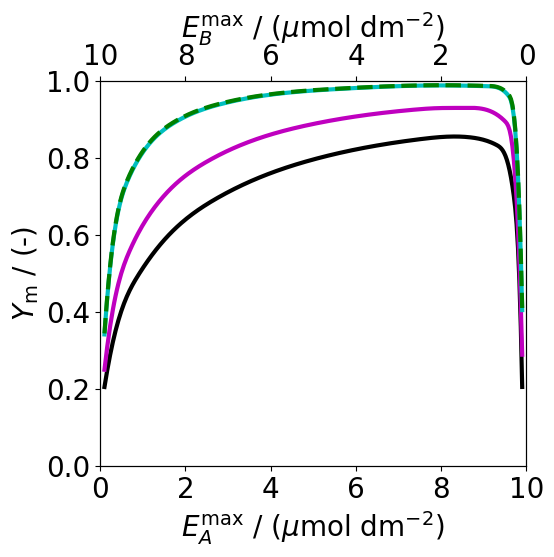

In [6]:
# Visualization
import pandas as pd
from scipy.interpolate import UnivariateSpline
%matplotlib inline
# 1. Import data
df = pd.read_csv("output/all_sid_optim.csv")

# 2. Figure
fig = plt.figure(figsize=(5.5,5))
ax1 = fig.add_subplot(111)

# 3. Style map
style_map = {
    'beta':   ('black', 'beta'),
    'gamma':  ('m', 'gamma'),
    'theta1': ('c', 'theta1'),
    'theta2': ('g', 'theta2')
}

# 4. Spline interpolation + plotting
for group_name, group_data in df.groupby('immobilization'):

    group_data = group_data.sort_values('EA_max')

    x = group_data['EA_max'].values
    y = group_data['S3_yield'].values

    color, label = style_map[group_name]

    # spline smoothing (small smoothing avoids oscillation)
    spline = UnivariateSpline(x, y, s=0.0001)

    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = spline(x_smooth)

    # Thick interpolated line
    if group_name == 'theta2':
        ax1.plot(x_smooth, y_smooth, color,
            linewidth=3, linestyle='--',
            label=label
        )
    else:
        ax1.plot(x_smooth, y_smooth, color,
            linewidth=3,
            label=label
        )

    # Real data points
    # ax1.plot(x, y, color + 'X', markersize=10, markeredgewidth=2)

# 5. Axis formatting
ax1.set_ylim(0,1)
ax1.set_xlim(0,10)

ax2 = ax1.twiny()
ax2.set_xticks(ax1.get_xticks())
ax2.set_xbound(ax1.get_xbound())
ax2.set_xticklabels([10 - int(x) for x in ax1.get_xticks()])
# Labels
ax1.set_xlabel('$\\it{E}_A^{\\mathrm{max}}$ / ($\\mu$mol dm$^{-2}$)', fontsize=20)
ax1.set_ylabel('$\\it{Y}$$_\\mathrm{m}$ / (-)', fontsize=20)
ax2.set_xlabel('$\\it{E}_B^{\\mathrm{max}}$ / ($\\mu$mol dm$^{-2}$)', fontsize=20)
# Tick formatting
ax1.tick_params(axis='both', which='major', labelsize=20)
ax2.tick_params(axis='both', which='major', labelsize=20)
# Legend
# ax1.legend(fontsize=10)
# Save
# fig.savefig('optimization.pdf', bbox_inches='tight')

plt.show()

## 4. Monte Carlo Parameter Uncertainty Analysis

To evaluate the robustness of our selected SIDs against kinetic uncertainty, we perform Monte Carlo simulations. Using Latin Hypercube Sampling (LHS) in log-space, we draw random parameter sets covering standard deviations in catalytic turnover constants ($k_A, k_B$) and substrate diffusivities ($D_1, D_2$). 

This assesses whether a specific spatial design strictly outperforms another across a wide window of physical realities.

In [ ]:
# Code for Monte Carlo execution using application.monte_carlo can be added here
# e.g. monte_carlo.run_mc_simulations(...)


## 4. Monte Carlo Parameter Uncertainty Analysis

To evaluate the robustness of our selected Spatial Immobilization Designs (SIDs) against kinetic and mass-transfer uncertainty, we perform Monte Carlo (MC) simulations. 

First, we use uniform sampling in log-space to draw a statistically representative set of random parameters, **Latin Hypercube Sampling (LHS)** is also available. We vary the catalytic turnover constants ($k_A, k_B$) and substrate diffusivities ($D_1, D_2$) across defined bounds, while uniformly sampling the total enzyme budget ($E_{A,max}$, $E_{B,max}$).

$$f_{\mathrm{FOK}} = \frac{E_A^{\max} \cdot k_A \cdot D_1}{E_B^{\max} \cdot k_B \cdot D_2}$$

In [16]:
import application.monte_carlo as mc
from visualization.monte_carlo_viz import *
# 1. Define bounds for independent physical parameters
param_bounds = {
    'k_A': (1e-1, 1000),
    'k_B': (1e-1, 1000),
    'D_1': (1e-8, 1e-5),
    'D_2': (1e-8, 1e-5)
}

# 2. Generate and save LHS parameter samples
sample_file_path = "output/mc_samples_2000.csv"
N_SAMPLES = 2000

mc_samples_df = mc.generate_parameter_samples(
    N=N_SAMPLES,
    bounds=param_bounds,
    method="log",
    seed=42,          # Fixed seed for reproducibility
    save_path=sample_file_path
)

print(f"Generated {len(mc_samples_df)} parameter combinations.")
mc_samples_df.head()

Parameter samples saved to: output/mc_samples_2000.csv
Generated 2000 parameter combinations.


,E_A_max,E_B_max,k_A,k_B,D_1,D_2
0,7.191648,2.808352,234.924264,73.181260,2.325033e-07,4.763915e-07
1,4.511028,5.488972,6.103205,2.682022,2.272867e-08,4.933921e-06
2,7.868783,2.131217,648.486062,255.547374,5.099414e-07,6.826143e-08
3,6.578944,3.421056,40.103138,0.920256,2.946365e-08,1.196555e-08
4,1.753419,8.246581,0.290801,14.242098,1.523614e-08,2.123073e-06


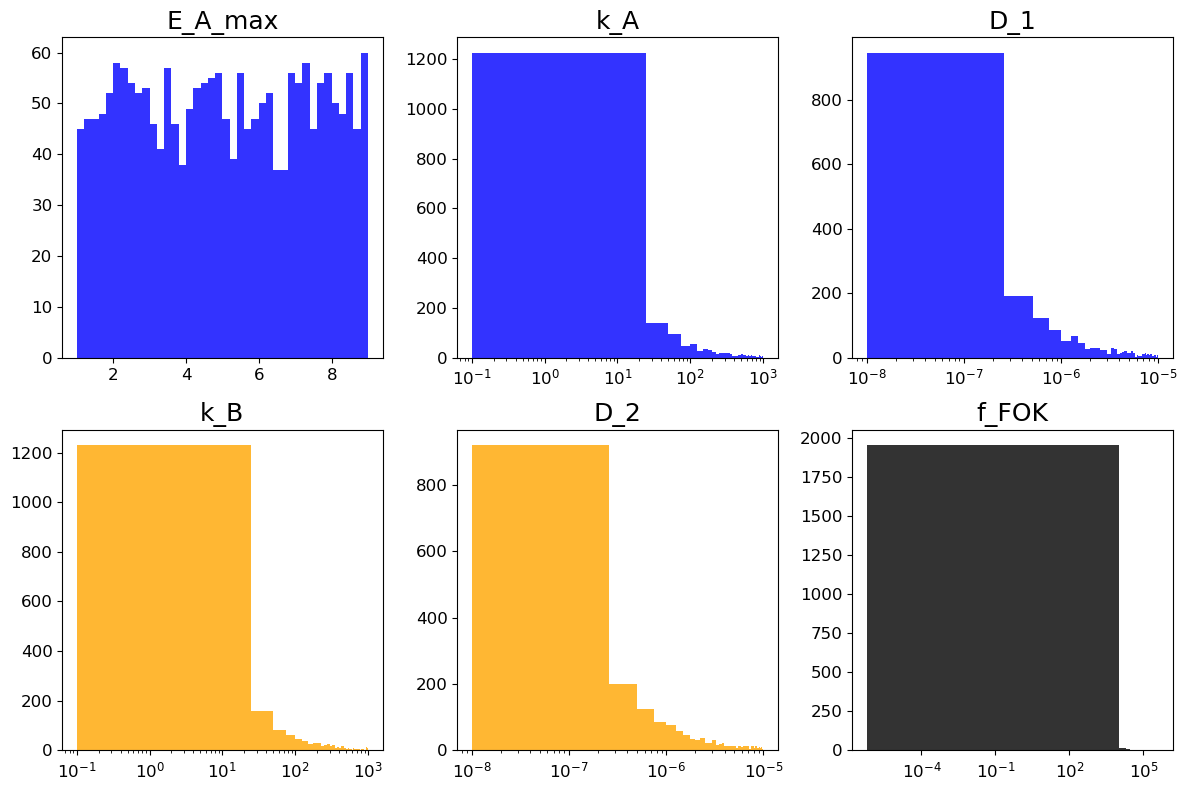

In [17]:
fig = plot_parameter_distributions(mc_samples_df)
%matplotlib inline
plt.show()

### 4.1 Execute Comparative Simulation

With our parameter space sampled, we now iteratively solve the reactor multiscale model for two competing architectures over every parameter set. Here, we compare the uniform **$\beta$-SID** against the core-shell **$\theta_1$-SID**.

*Note: The `run_monte_carlo_simulation` function has a built-in progress saver. If the kernel is interrupted, re-running the cell will pick up exactly where it left off by checking for `NaN` values in the output columns.*

In [18]:
# Run the Monte Carlo simulation evaluating both profiles for each sampled row.
# We set n_runs=5 here for a quick demonstration. Set n_runs=None to process the entire dataset.

mc_results_df = mc.run_monte_carlo_simulation(
    samples_csv=sample_file_path,
    bvp_profile_1=bvp_kwargs_beta,     # Defined in Section 3
    bvp_profile_2=bvp_kwargs_theta1,   # Defined in Section 3
    decay_coef={'kA': 0, 'kB': 0},     # Assuming no decay for this specific study
    n_runs=5,                          # Limit runs for demonstration purposes
    bvp1_col='beta_S3_yield',
    bvp2_col='theta1_S3_yield',
    save_path="mc_results_beta_vs_theta1.csv",
    verbose=True,
    solver_tol=1e-3
)

# Display the rows that have completed the simulation successfully
completed_runs = mc_results_df.dropna(subset=['beta_S3_yield', 'theta1_S3_yield'])
completed_runs[['E_A_max', 'E_B_max', 'beta_S3_yield', 'theta1_S3_yield']].head()

[MC] Total pending rows to run: 5
[MC] Decay coefficients: kA=0, kB=0

[MC] Run 1/5  (df index=0)
     EA=7.192  EB=2.808  kA=234.9  kB=73.18  D1=2.325e-07  D2=4.764e-07
  -> Profile: beta_S3_yield
Discretizing model...
Applying initial guesses for BVP...
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.19\x3a Converged to a locally infeasible
      point. Problem may be infeasible.
     [FAIL] infeasible
  -> Profile: theta1_S3_yield
Discretizing model...
Applying initial guesses for BVP...
     [OK] S3_yield = 0.9913
  -> Saved. Completed rows so far: 0/2000

[MC] Run 2/5  (df index=1)
     EA=4.511  EB=5.489  kA=6.103  kB=2.682  D1=2.273e-08  D2=4.934e-06
  -> Profile: beta_S3_yield
Discretizing model...
Applying initial guesses for BVP...
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.19\x3a Converged to a locally infeasible
      point. Problem may be infeasible.
     [FAIL] inf

,E_A_max,E_B_max,beta_S3_yield,theta1_S3_yield
4,1.753419,8.246581,0.069873,0.053942


Here is the pair-plot for the previously done 100-run Monte Carlo sampling of the parameter space. This pairplot correlates the product yield ($Y_m$) of the uniform co-immobilization ($\beta$-SID) against the stepwise stratified design ($\theta_1$-SID) for each randomized set of kinetics and transport properties. The points are color-coded by the modulus ratio ($f_{\mathrm{FOK}}$)

Points appearing above the dashed $y=x$ diagonal indicate regimes where the $\theta_1$ configuration outperforms the $\beta$ baseline, typically occurring when Enzyme A is significantly more "potent" than Enzyme B, or when diffusion limitations for the primary substrate are severe.

**_Note: In the given dataset, yield = 999 means infeasible result from the solver_**

[plot_mc_pairplot] Valid rows: 103  |  Dropped (out of [0,1]): 97


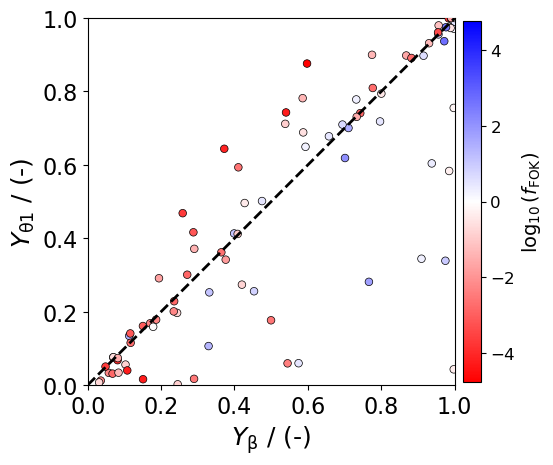

In [19]:
%matplotlib inline
fig1, ax1 = plot_mc_pairplot(
    "output/mc_run_small.csv",
    bvp1_col='bvp1_S3_yield',
    bvp2_col='bvp2_S3_yield',
    bvp1_label='\\beta',
    bvp2_label='\\theta1',
    alpha=1,
    s=30,
    save_path=None,
    show=False,
)